# 274. The k-sizes to test for each kmerseek alphabet, from $k_\mathrm{min}$ to $k_\mathrm{max}$

**Question.** For each of kmerseek's 19 alphabets, which seed lengths $k$ should the benchmark
run? A seed that is too short matches by chance in too many proteins; a seed that is too long
stops matching between real homologs. This notebook draws the publication version of Figure 12
of the [Information content per alphabet](https://claude.ai/artifact/H4cCWq5uhBHDk4rDj4nEz8)
explainer, which answers this with one range of $k$ per alphabet.

**Decision rule, written before running.** The range is every whole number $k$ from
$k_\mathrm{min}$ to $k_\mathrm{max}$ (definitions below). The code must first reproduce the
explainer's values for all 19 alphabets with the explainer's human proteome size of 11 million
residues; if any value differs, the figure is not drawn. The figure then uses the real residue
count of the human proteome FASTA, and any alphabet whose $k$ changes because of that is
listed.

**Data.**
- Seed counts in the human proteome: `tables/250_two_k_per_alphabet.csv`, written by
  `scripts/elm_seed_floor.py` for notebook 250
  ([PR #51](https://github.com/seanome/2024-kmerseek-analysis/pull/51)). kmerseek 0.4.0
  (image `kmerseek-region:0.4.0-rc5-arm64`) indexed the QfO release 2020_04 human proteome,
  `Eukaryota/UP000005640_9606.fasta`, and counted, for each $k$, how many proteins share a seed
  drawn at a random position ("proteins per seed", $P(k)$, which includes the protein the seed
  came from).
- Amino-acid composition of UniProtKB/Swiss-Prot release 2026_03 (575,748 entries,
  209,017,843 residues), section 6.1 of
  [the release statistics](https://web.expasy.org/docs/relnotes/relstat.html).
- Letter classes of each alphabet: `src/rust/alphabets.rs` of
  [seanome/kmerseek](https://github.com/seanome/kmerseek) at tag v0.4.0; dayhoff6 is encoded by
  sourmash, so its classes come from `notebooks/hp_conservation_utils.py`.

**Definitions.**
- $k_\mathrm{main}$: the shortest $k$ at which seeds are shared by fewer than 100 human proteins
  on average ($P(k) < 100$, each seed weighted by how often it occurs), measured by kmerseek in
  notebook 250.
- Bits per letter $B$: how much one matching letter narrows the search. Each extra letter
  divides the number of chance matches by $2^B$.
- $B_\mathrm{comp}$, bits per letter from composition: $B_\mathrm{comp} = -\log_2 \sum_c q_c^2$,
  where $q_c$ is the share of Swiss-Prot residues in letter class $c$. $\sum_c q_c^2$ is the
  chance that two residues drawn at random fall in the same class.
- $B_\mathrm{human}$, bits per letter measured in the human proteome, from the two measured seed
  lengths $k_\mathrm{small} < k_\mathrm{main}$:
  $B_\mathrm{human} = \dfrac{\log_2(P(k_\mathrm{small}) - 1) - \log_2(P(k_\mathrm{main}) - 1)}{k_\mathrm{main} - k_\mathrm{small}}$
  (the $-1$ removes the protein the seed came from).
- Equation 4b of the explainer: the shortest $k$ at which a seed expects at most `allowed`
  chance matches in a database of $N$ residues,
  $k(N, \mathrm{allowed}, B) = \left\lceil \dfrac{\log_2 N - \log_2 \mathrm{allowed}}{B} \right\rceil$.
- $k_\mathrm{min} = \min(k_\mathrm{main},\ k(N_\mathrm{human}, 100, B_\mathrm{comp}))$, the low end.
- $k^* = k(209{,}017{,}843,\ 1,\ B_\mathrm{comp})$: one chance match in Swiss-Prot.
- $k_\mathrm{max} = k(209{,}017{,}843,\ 1,\ B_\mathrm{human})$, the high end. It is an estimate:
  the formula with a measured input.

In [1]:
from __future__ import annotations

import math
import re
import subprocess
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.lines import Line2D

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "notebooks"))
import hp_conservation_utils as hc  # noqa: E402

pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

SEED_TABLE = REPO / "tables" / "250_two_k_per_alphabet.csv"
HUMAN_FASTA = Path(
    "/Users/olga/data/quest-for-orthologs/QfO_release_2020_04_with_updated_UP000008143"
    "/Eukaryota/UP000005640_9606.fasta"
)
KMERSEEK_REPO = Path("/Users/olga/code/kmerseek")
KMERSEEK_TAG = "v0.4.0"
CLASSES_CACHE = REPO / "tables" / "274_alphabet_classes_kmerseek_v0.4.0.csv"
OUT_TABLE = REPO / "tables" / "274_ksizes_to_test_per_alphabet_human_swissprot.csv"
FIG_STEM = REPO / "figures" / "274_ksizes_to_test_per_alphabet_human_swissprot"

# UniProtKB/Swiss-Prot release 2026_03, "6.1 Composition in percent for the complete
# database", https://web.expasy.org/docs/relnotes/relstat.html
SWISSPROT_RELEASE = "2026_03"
SWISSPROT_ENTRIES = 575_748
SWISSPROT_RESIDUES = 209_017_843
SWISSPROT_PERCENT = {
    "A": 8.25, "Q": 3.93, "L": 9.64, "S": 6.66,
    "R": 5.52, "E": 6.71, "K": 5.79, "T": 5.36,
    "N": 4.06, "G": 7.07, "M": 2.41, "W": 1.10,
    "D": 5.46, "H": 2.27, "F": 3.86, "Y": 2.92,
    "C": 1.38, "I": 5.90, "P": 4.75, "V": 6.85,
}  # fmt: skip

ALLOWED_HUMAN = 100  # chance matches per seed at the low end, as for k_main
ALLOWED_SWISSPROT = 1  # chance matches per seed at k* and k_max
N_HUMAN_EXPLAINER = 11_000_000  # the human proteome size the explainer used

# Row order: by letter count, as in Figure 2 of the explainer.
ORDER = [
    "protein20", "uniprot18", "hsdm17", "wass14", "mmseqs12", "sdm12",
    "funcgroups8", "gbmr7", "dayhoff6", "wwmj5", "gbmr4", "polarity4",
    "hp_lehninger_hpc3", "hp_kyte_doolittle2", "hp_lehninger_c_nonpolar2", "hp_lehninger2",
    "hp_pbotc_1st_ed2", "hp_thomas_dill_no_c2", "hp_thomas_dill2",
]  # fmt: skip

## 1. Inputs: the human proteome size, the letter classes and the seed table

The human proteome size $N_\mathrm{human}$ is the number of residues in the FASTA file
kmerseek indexed for notebook 250. Every letter of every sequence is counted, including the
rare `X` and `U`.

In [2]:
def fasta_residue_counts(path: Path) -> tuple[int, int, dict[str, int]]:
    '''Number of sequences, number of residues, and the count of each residue letter.'''
    n_seqs = 0
    letters: dict[str, int] = {}
    with open(path) as fh:
        for line in fh:
            if line.startswith(">"):
                n_seqs += 1
                continue
            for ch in line.strip():
                letters[ch] = letters.get(ch, 0) + 1
    return n_seqs, sum(letters.values()), letters


n_human_proteins, N_HUMAN, human_letters = fasta_residue_counts(HUMAN_FASTA)
nonstandard = {aa: n for aa, n in human_letters.items() if aa not in SWISSPROT_PERCENT}
print(f"Human proteome FASTA: {HUMAN_FASTA.name}")
print(f"  proteins: {n_human_proteins:,}")
print(f"  residues, N_human: {N_HUMAN:,}  (the explainer used {N_HUMAN_EXPLAINER:,})")
print(f"  letters other than the 20 amino acids: {nonstandard}")
print(f"Swiss-Prot {SWISSPROT_RELEASE}: {SWISSPROT_ENTRIES:,} entries, {SWISSPROT_RESIDUES:,} residues")
print(f"  composition percentages sum to {sum(SWISSPROT_PERCENT.values()):.2f} "
      "(rounded to two decimals by UniProt); shares below are divided by this sum")

Human proteome FASTA: UP000005640_9606.fasta
  proteins: 20,600
  residues, N_human: 11,395,293  (the explainer used 11,000,000)
  letters other than the 20 amino acids: {'X': 67, 'U': 36}
Swiss-Prot 2026_03: 575,748 entries, 209,017,843 residues
  composition percentages sum to 99.89 (rounded to two decimals by UniProt); shares below are divided by this sum


The letter classes are read from kmerseek's own source at tag v0.4.0, the version that
counted the seeds, and cached to `tables/274_alphabet_classes_kmerseek_v0.4.0.csv`. The
classes `hp_conservation_utils` holds for the same alphabets must agree with them.

In [3]:
def classes_from_alphabets_rs(source: str) -> dict[str, list[str]]:
    '''Letter classes of every alphabet defined in kmerseek's src/rust/alphabets.rs.

    Cluster tables (``const GBMR4_CLUSTERS: &[&str] = &[...]``) give the multi-letter
    alphabets; ``build_hp``/``build_hpc`` calls give the hydrophobic-polar family, matched to
    their names through ``partition()`` and ``to_moltype()``. protein20 is the 20 amino
    acids, each its own letter. dayhoff6 is encoded by sourmash and is not in this file.
    '''
    classes: dict[str, list[str]] = {"protein20": list("ACDEFGHIKLMNPQRSTVWY")}
    for const, body in re.findall(r"const (\w+)_CLUSTERS: &\[&str\] =\s*&\[(.*?)\];", source, re.S):
        classes[const.lower()] = re.findall(r'"([A-Z]+)"', body)
    statics = {
        name: re.findall(r'b"([A-Z]+)"', args)
        for name, args in re.findall(
            r"static (\w+): LazyLock<HashMap<u8, u8>> =\s*LazyLock::new\(\|\| build_hpc?\((.*?)\)\);",
            source,
            re.S,
        )
    }
    variant_to_static = dict(re.findall(r"Self::(Hp\w+) => &(\w+),", source))
    variant_to_name = dict(re.findall(r'Self::(Hp\w+) => "(hp_\w+)",', source))
    for variant, static in variant_to_static.items():
        classes[variant_to_name[variant]] = statics[static]
    return classes


if KMERSEEK_REPO.exists():
    rs = subprocess.run(
        ["git", "-C", str(KMERSEEK_REPO), "show", f"{KMERSEEK_TAG}:src/rust/alphabets.rs"],
        check=True, capture_output=True, text=True,
    ).stdout
    classes = classes_from_alphabets_rs(rs)
    classes["dayhoff6"] = hc.ALPHABET_CLUSTERS["dayhoff6"]
    pl.DataFrame(
        {"alphabet": list(classes), "letter_classes": [" ".join(c) for c in classes.values()]}
    ).write_csv(CLASSES_CACHE)
    print(f"read from {KMERSEEK_REPO}/src/rust/alphabets.rs at {KMERSEEK_TAG}; cached to {CLASSES_CACHE.name}")
else:
    classes = {
        r["alphabet"]: r["letter_classes"].split()
        for r in pl.read_csv(CLASSES_CACHE).iter_rows(named=True)
    }
    print(f"kmerseek repo not found; read the cached {CLASSES_CACHE.name}")

assert set(classes) == set(ORDER), set(classes) ^ set(ORDER)
for name, cl in classes.items():
    assert sorted("".join(cl)) == sorted(SWISSPROT_PERCENT), f"{name} does not cover the 20 amino acids once"
as_sets = lambda cl: {frozenset(c) for c in cl}  # noqa: E731
for name, cl in hc.ALPHABET_CLUSTERS.items():
    if name in classes:
        assert as_sets(cl) == as_sets(classes[name]), f"{name}: hp_conservation_utils differs from alphabets.rs"
print(f"{len(classes)} alphabets, each covering the 20 amino acids once; "
      f"{len(set(hc.ALPHABET_CLUSTERS) & set(classes))} also in hp_conservation_utils, all identical")

read from /Users/olga/code/kmerseek/src/rust/alphabets.rs at v0.4.0; cached to 274_alphabet_classes_kmerseek_v0.4.0.csv
19 alphabets, each covering the 20 amino acids once; 15 also in hp_conservation_utils, all identical


## 2. Bits per letter and the k-sizes to test

For each alphabet: $B_\mathrm{comp}$ from the Swiss-Prot composition, $B_\mathrm{human}$ from the
two measured seed lengths, then Equation 4b three times. The `_exact` columns are the value
inside the ceiling, so a $k$ that sits just above a whole number is visible.
`tables/250_two_k_per_alphabet.csv` has no bits-per-letter column, so $B_\mathrm{human}$ is
computed here from its seed counts.

In [4]:
def k_eq4b_exact(n_residues: float, allowed: float, bits_per_letter: float) -> float:
    '''Equation 4b before rounding up: (log2 N - log2 allowed) / B.'''
    return (math.log2(n_residues) - math.log2(allowed)) / bits_per_letter


def k_eq4b(n_residues: float, allowed: float, bits_per_letter: float) -> int:
    '''Equation 4b: the shortest k with at most `allowed` chance matches in N residues.'''
    return math.ceil(k_eq4b_exact(n_residues, allowed, bits_per_letter))


def bits_from_composition(letter_classes: list[str]) -> float:
    total = sum(SWISSPROT_PERCENT.values())
    shares = [sum(SWISSPROT_PERCENT[aa] for aa in c) / total for c in letter_classes]
    return -math.log2(sum(q * q for q in shares))


def bits_from_human_seed_counts(row: dict) -> float:
    drop = math.log2(row["proteins_per_seed_k_small"] - 1) - math.log2(row["proteins_per_seed_k_main"] - 1)
    return drop / (row["k_main"] - row["k_small"])


seeds = {r["alphabet"]: r for r in pl.read_csv(SEED_TABLE).iter_rows(named=True)}
assert set(seeds) == set(ORDER), set(seeds) ^ set(ORDER)
assert not any("bit" in c for c in pl.read_csv(SEED_TABLE).columns)


def ksize_row(name: str, n_human: float) -> dict:
    r = seeds[name]
    b_comp = bits_from_composition(classes[name])
    b_human = bits_from_human_seed_counts(r)
    k_h100 = k_eq4b(n_human, ALLOWED_HUMAN, b_comp)
    k_star = k_eq4b(SWISSPROT_RESIDUES, ALLOWED_SWISSPROT, b_comp)
    k_max = k_eq4b(SWISSPROT_RESIDUES, ALLOWED_SWISSPROT, b_human)
    k_min = min(r["k_main"], k_h100)
    return {
        "alphabet": name,
        "n_letters": len(classes[name]),
        "letter_classes": " ".join(classes[name]),
        "B_comp": round(b_comp, 4),
        "B_human": round(b_human, 4),
        "k_small": r["k_small"],
        "k_main": r["k_main"],
        "proteins_per_seed_k_small": r["proteins_per_seed_k_small"],
        "proteins_per_seed_k_main": r["proteins_per_seed_k_main"],
        "k_human100_exact": round(k_eq4b_exact(n_human, ALLOWED_HUMAN, b_comp), 3),
        "k_human100": k_h100,
        "k_star_exact": round(k_eq4b_exact(SWISSPROT_RESIDUES, ALLOWED_SWISSPROT, b_comp), 3),
        "k_star": k_star,
        "k_max_exact": round(k_eq4b_exact(SWISSPROT_RESIDUES, ALLOWED_SWISSPROT, b_human), 3),
        "k_max": k_max,
        "k_min": k_min,
        "n_ksizes": k_max - k_min + 1,
        "ksizes": ",".join(str(k) for k in range(k_min, k_max + 1)),
    }


# Columns: k_main, k(N_human, 100, B_comp), k*, k_max, number of k-sizes, with N_human = 11e6.
EXPECTED_EXPLAINER = {
    "protein20": (5, 5, 7, 8, 4), "uniprot18": (5, 5, 8, 9, 5), "hsdm17": (5, 6, 9, 10, 6),
    "wass14": (5, 5, 9, 9, 5), "mmseqs12": (6, 6, 9, 10, 5), "sdm12": (7, 6, 10, 12, 7),
    "funcgroups8": (7, 8, 13, 14, 8), "gbmr7": (13, 14, 23, 35, 23), "dayhoff6": (9, 8, 14, 18, 11),
    "wwmj5": (9, 9, 14, 15, 7), "gbmr4": (14, 13, 22, 28, 16), "polarity4": (12, 11, 18, 25, 15),
    "hp_lehninger_hpc3": (17, 17, 27, 29, 13), "hp_kyte_doolittle2": (20, 19, 30, 39, 21),
    "hp_lehninger_c_nonpolar2": (18, 17, 28, 31, 15), "hp_lehninger2": (17, 17, 28, 30, 14),
    "hp_pbotc_1st_ed2": (18, 17, 28, 30, 14), "hp_thomas_dill_no_c2": (20, 18, 29, 39, 22),
    "hp_thomas_dill2": (19, 18, 29, 36, 19),
}  # fmt: skip
assert list(EXPECTED_EXPLAINER) == ORDER
COMPARED = ["k_main", "k_human100", "k_star", "k_max", "n_ksizes"]
explainer = pl.DataFrame([ksize_row(a, N_HUMAN_EXPLAINER) for a in ORDER])
mismatch = [
    (r["alphabet"], tuple(r[c] for c in COMPARED), EXPECTED_EXPLAINER[r["alphabet"]])
    for r in explainer.iter_rows(named=True)
    if tuple(r[c] for c in COMPARED) != EXPECTED_EXPLAINER[r["alphabet"]]
]
assert not mismatch, mismatch
print(f"With N_human = {N_HUMAN_EXPLAINER:,}: all {len(ORDER)} alphabets reproduce the explainer's "
      f"{', '.join(COMPARED)}.")

table = pl.DataFrame([ksize_row(a, N_HUMAN) for a in ORDER])
changed = table.join(explainer, on="alphabet", suffix="_11M").filter(
    (pl.col("k_human100") != pl.col("k_human100_11M")) | (pl.col("k_min") != pl.col("k_min_11M"))
    | (pl.col("n_ksizes") != pl.col("n_ksizes_11M"))
)
print(f"\nWith the real N_human = {N_HUMAN:,}, alphabets whose k changes:")
print(changed.select("alphabet", "k_main", "k_human100_exact_11M", "k_human100_11M", "k_human100_exact",
                     "k_human100", "k_min_11M", "k_min", "n_ksizes_11M", "n_ksizes"))
table.write_csv(OUT_TABLE)
print(f"\nWrote {OUT_TABLE.relative_to(REPO)}; the figure below draws these rows:")
print(table.select(
    "alphabet", "n_letters", "B_comp", "B_human", "k_main", "k_human100_exact", "k_human100",
    "k_star_exact", "k_star", "k_max_exact", "k_max", "k_min", "n_ksizes", "ksizes",
))

With N_human = 11,000,000: all 19 alphabets reproduce the explainer's k_main, k_human100, k_star, k_max, n_ksizes.

With the real N_human = 11,395,293, alphabets whose k changes:
shape: (1, 10)
┌──────────┬────────┬──────────────────────┬────────────────┬──────────────────┬────────────┬───────────┬───────┬──────────────┬──────────┐
│ alphabet ┆ k_main ┆ k_human100_exact_11M ┆ k_human100_11M ┆ k_human100_exact ┆ k_human100 ┆ k_min_11M ┆ k_min ┆ n_ksizes_11M ┆ n_ksizes │
│ ---      ┆ ---    ┆ ---                  ┆ ---            ┆ ---              ┆ ---        ┆ ---       ┆ ---   ┆ ---          ┆ ---      │
│ str      ┆ i64    ┆ f64                  ┆ i64            ┆ f64              ┆ i64        ┆ i64       ┆ i64   ┆ i64          ┆ i64      │
╞══════════╪════════╪══════════════════════╪════════════════╪══════════════════╪════════════╪═══════════╪═══════╪══════════════╪══════════╡
│ sdm12    ┆ 7      ┆ 5.987                ┆ 6              ┆ 6.005            ┆ 7          ┆ 6         ┆ 

### Figure 274: the k-sizes to test per alphabet

How to read it: each row is one alphabet. The grey bar runs from $k_\mathrm{min}$ to
$k_\mathrm{max}$, one cell per k-size the benchmark would run, and the "# k-sizes" column at the
right counts the cells. Magenta marks
are about the human proteome at about 100 proteins per seed; the teal and purple dots are about
one chance match in Swiss-Prot. Only the magenta diamond is measured; the other three marks come
from Equation 4b. The decision it informs: how many indexes to build per alphabet. The four
widest ranges, gbmr7 (23 k-sizes), hp_thomas_dill_no_c2 (22), hp_kyte_doolittle2 (21) and
hp_thomas_dill2 (19), belong to the four alphabets with the fewest bits per letter measured in
the human proteome (0.71 to 0.80), so each extra letter adds little and $k_\mathrm{max}$ sits
far out.

Size: 89 mm wide, one Nature Biotechnology column. The figure legend is in
`figures/274_ksizes_to_test_per_alphabet_human_swissprot_legend.md`.

legend layout, inches: {'column 1 ends': 1.705, 'column 2 starts': 1.86, 'column 2 ends': 3.19, 'cell line ends': 2.527, 'note ends': 3.178, 'figure width': 3.504}
figure 89.0 x 87.2 mm; widest name 'hp_lehninger_c_nonpolar2' ends 1.52 mm before the plot
229 bar cells drawn = sum of n_ksizes over 19 alphabets


saved figures/274_ksizes_to_test_per_alphabet_human_swissprot.pdf


saved figures/274_ksizes_to_test_per_alphabet_human_swissprot.svg


saved figures/274_ksizes_to_test_per_alphabet_human_swissprot.png


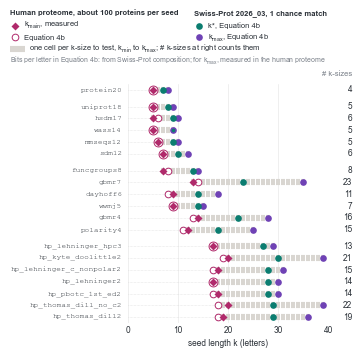

In [5]:
# Journal-safe fonts: Arial for text, Courier New for alphabet names (both TrueType, embedded in the PDF).
SANS, MONO_FAMILY = "Arial", "Courier New"
for family in (SANS, MONO_FAMILY):
    assert fm.findfont(family, fallback_to_default=False)
MONO = fm.FontProperties(family=MONO_FAMILY)
mpl.rcParams.update({
    "font.family": SANS, "font.size": 6, "mathtext.fontset": "custom",
    "mathtext.rm": SANS, "mathtext.it": SANS, "mathtext.bf": f"{SANS}:bold",
    "pdf.fonttype": 42, "svg.fonttype": "path", "xtick.labelsize": 6,
})

MAGENTA, TEAL, PURPLE = "#b02a6b", "#0b7d70", "#6f42b5"
CELL = "#d9d6d1"  # one bar cell per k-size to test
GRID, GUIDE, MUTED, INK = "#e9e9e9", "#d4d4d4", "#7a8089", "#2b3138"
MM = 1 / 25.4
FIG_W = 89 * MM
NAME_PT, TEXT_PT, NOTE_PT = 5.5, 6.0, 5.5
LEGEND_PT, LEGEND_NOTE_PT = 5.5, 5.0  # Arial runs wide; the legend must fit in 89 mm
ROW_IN = 0.118  # one alphabet row, inches
GROUP_GAP_IN = 0.05  # extra space between letter-count groups (20; 12-18; 4-8; 2-3)
SIZE_GROUPS = [(20, 20), (12, 18), (4, 8), (2, 3)]
X_LIM = (0, 40)
CELL_W, CELL_GAP = 4.4, 0.16  # bar height in points; white gap between cells, in letters of k
DIAMOND, RING, RING_AROUND, DOT, DOT_INSIDE, RING_W = 4.4, 4.8, 6.4, 4.8, 2.6, 0.7  # points
# RING_AROUND: the ring drawn larger where it falls on the same k as the diamond, so both show

# Vertical layout, inches from the top: legend, rows, x axis.
LEGEND_TOP, LEGEND_LINE = 0.03, 0.118
n_legend_lines = 5
plot_top = LEGEND_TOP + n_legend_lines * LEGEND_LINE + 0.17
rows_y: dict[str, float] = {}
y = 0.0
for lo, hi in SIZE_GROUPS:
    y += GROUP_GAP_IN if rows_y else 0.0
    for name in ORDER:
        if lo <= len(classes[name]) <= hi:
            rows_y[name] = y + 0.5 * ROW_IN
            y += ROW_IN
assert list(rows_y) == ORDER
rows_h = y
AXIS_BELOW = 0.25
FIG_H = plot_top + rows_h + AXIS_BELOW
NAME_RIGHT, PLOT_LEFT, PLOT_RIGHT, COUNT_RIGHT = 1.14, 1.20, FIG_W - 0.30, FIG_W - 0.06

fig = plt.figure(figsize=(FIG_W, FIG_H))
ax = fig.add_axes([PLOT_LEFT / FIG_W, AXIS_BELOW / FIG_H, (PLOT_RIGHT - PLOT_LEFT) / FIG_W, rows_h / FIG_H])
ax.set_xlim(*X_LIM)
ax.set_ylim(rows_h / ROW_IN, 0)  # y in rows, top = 0
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(axis="x", length=0, colors=MUTED, labelcolor=INK, pad=2)
ax.set_yticks([])
ax.set_xticks(range(X_LIM[0], X_LIM[1] + 1, 10))
ax.set_xlabel("seed length k (letters)", fontsize=TEXT_PT, labelpad=3, color=INK)
for x in range(X_LIM[0], X_LIM[1] + 1, 10):
    ax.axvline(x, color=GRID, lw=0.5, zorder=0)

inch_to_fig_y = lambda yin: 1 - (plot_top + yin) / FIG_H  # noqa: E731
n_cells_drawn = 0
for name in ORDER:
    r = table.row(by_predicate=pl.col("alphabet") == name, named=True)
    yy = rows_y[name] / ROW_IN
    # faint dotted guide from the axis to the start of the bar, so a bar far to the right reads back to its name
    ax.plot([X_LIM[0], r["k_min"] - 0.5], [yy, yy], color=GUIDE, lw=0.4, ls=(0, (1, 1.5)), zorder=0)
    for k in range(r["k_min"], r["k_max"] + 1):
        ax.plot([k - 0.5 + CELL_GAP / 2, k + 0.5 - CELL_GAP / 2], [yy, yy], color=CELL, lw=CELL_W,
                solid_capstyle="butt", zorder=1, gid="cell")
        n_cells_drawn += 1
    ax.plot(r["k_max"], yy, "o", ms=DOT, mfc=PURPLE, mec="none", zorder=3)
    teal_ms = DOT_INSIDE if r["k_star"] == r["k_max"] else DOT
    ax.plot(r["k_star"], yy, "o", ms=teal_ms, mfc=TEAL, mec="none", zorder=4)
    ring_ms = RING_AROUND if r["k_human100"] == r["k_main"] else RING
    ax.plot(r["k_human100"], yy, "o", ms=ring_ms, mfc="white", mec=MAGENTA, mew=RING_W, zorder=5)
    ax.plot(r["k_main"], yy, "D", ms=DIAMOND, mfc=MAGENTA, mec="none", zorder=6)
    fig.text(NAME_RIGHT / FIG_W, inch_to_fig_y(rows_y[name]), name, fontproperties=MONO,
             fontsize=NAME_PT, ha="right", va="center", color=INK, gid="name")
    fig.text(COUNT_RIGHT / FIG_W, inch_to_fig_y(rows_y[name]), f"{r['n_ksizes']}",
             fontsize=TEXT_PT, ha="right", va="center", color=INK, gid="count")
fig.text(COUNT_RIGHT / FIG_W, inch_to_fig_y(-0.6 * ROW_IN), "# k-sizes", fontsize=NOTE_PT,
         ha="right", va="bottom", color=MUTED, gid="count_header")


# Legend above the plot, in two columns: the human-proteome marks and the Swiss-Prot marks.
renderer = fig.canvas.get_renderer()
LEG_LEFT, COL2_LEFT, GLYPH_W, GAP_AFTER_GLYPH = 0.02, 1.86, 0.10, 0.04
K_IN = (PLOT_RIGHT - PLOT_LEFT) / (X_LIM[1] - X_LIM[0])  # one letter of k on the x axis, in inches


def legend_glyph(x_in: float, y_in: float, kind: str) -> None:
    '''Draw one legend marker centred at (x_in, y_in), inches from the top-left corner.'''
    fy = 1 - y_in / FIG_H
    if kind == "cells":
        for i in (-1, 0, 1):
            cx = x_in + i * K_IN
            half = (1 - CELL_GAP) * K_IN / 2
            fig.add_artist(Line2D([(cx - half) / FIG_W, (cx + half) / FIG_W], [fy, fy], color=CELL,
                                  lw=CELL_W, solid_capstyle="butt", transform=fig.transFigure))
        return
    style = {
        "diamond": dict(marker="D", ms=DIAMOND, mfc=MAGENTA, mec="none"),
        "ring": dict(marker="o", ms=RING, mfc="white", mec=MAGENTA, mew=RING_W),
        "teal": dict(marker="o", ms=DOT, mfc=TEAL, mec="none"),
        "purple": dict(marker="o", ms=DOT, mfc=PURPLE, mec="none"),
    }[kind]
    fig.add_artist(Line2D([x_in / FIG_W], [fy], ls="none", transform=fig.transFigure, **style))


def text_width_in(t) -> float:
    return t.get_window_extent(renderer).width / fig.dpi


def put(x_in: float, y_in: float, s: str, **kw):
    return fig.text(x_in / FIG_W, 1 - y_in / FIG_H, s, ha="left", va="center", **kw)


def entry(x_in: float, y_in: float, kind: str, label: str, glyph_w: float = GLYPH_W) -> float:
    '''Legend glyph plus its label; returns the right edge, in inches.'''
    legend_glyph(x_in + glyph_w / 2, y_in, kind)
    t = put(x_in + glyph_w + GAP_AFTER_GLYPH, y_in, label, fontsize=LEGEND_PT, color=INK)
    return x_in + glyph_w + GAP_AFTER_GLYPH + text_width_in(t)


line_y = [LEGEND_TOP + (i + 0.5) * LEGEND_LINE for i in range(n_legend_lines)]
right_edges = []
for x0, header, items in (
    (LEG_LEFT, "Human proteome, about 100 proteins per seed",
     [("diamond", r"$k_\mathrm{main}$, measured"), ("ring", "Equation 4b")]),
    (COL2_LEFT, "Swiss-Prot 2026_03, 1 chance match",
     [("teal", "k*, Equation 4b"), ("purple", r"$k_\mathrm{max}$, Equation 4b")]),
):
    h = put(x0, line_y[0], header, fontsize=LEGEND_PT, weight="bold", color=INK)
    right_edges.append((x0, x0 + text_width_in(h)))
    for i, (kind, label) in enumerate(items):
        right_edges.append((x0, entry(x0, line_y[1 + i], kind, label)))
cells_right = entry(LEG_LEFT, line_y[3], "cells",
                    r"one cell per k-size to test, $k_\mathrm{min}$ to $k_\mathrm{max}$; # k-sizes at right counts them",
                    glyph_w=3 * K_IN)
note = put(LEG_LEFT, line_y[4], r"Bits per letter in Equation 4b: from Swiss-Prot composition; for $k_\mathrm{max}$, "
           "measured in the human proteome", fontsize=LEGEND_NOTE_PT, color=MUTED)
col1_right = max(x for x0, x in right_edges if x0 == LEG_LEFT)
col2_right = max(x for x0, x in right_edges if x0 == COL2_LEFT)
layout = {"column 1 ends": col1_right, "column 2 starts": COL2_LEFT, "column 2 ends": col2_right,
          "cell line ends": cells_right, "note ends": LEG_LEFT + text_width_in(note), "figure width": FIG_W}
print("legend layout, inches:", {k: round(float(v), 3) for k, v in layout.items()})
assert col1_right + 0.06 < COL2_LEFT, "legend column 1 runs into column 2"
assert max(col2_right, cells_right, layout["note ends"]) <= FIG_W - 0.02, "a legend line runs off the figure"


# Check that no text leaves the canvas and that names, plot and counts do not collide.
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
fig_box = fig.bbox
ax_box = ax.get_window_extent(renderer)
for t in fig.texts:
    bb = t.get_window_extent(renderer)
    assert bb.x0 >= fig_box.x0 - 0.5 and bb.x1 <= fig_box.x1 + 0.5, f"off the canvas: {t.get_text()}"
    assert bb.y0 >= fig_box.y0 - 0.5 and bb.y1 <= fig_box.y1 + 0.5, f"off the canvas: {t.get_text()}"
    if t.get_gid() == "name":
        assert bb.x1 < ax_box.x0, f"name runs into the plot: {t.get_text()}"
    if t.get_gid() == "count":
        assert bb.x0 > ax_box.x1, f"count runs into the plot: {t.get_text()}"
names = [t for t in fig.texts if t.get_gid() == "name"]
counts = [int(t.get_text()) for t in fig.texts if t.get_gid() == "count"]
assert counts == table["n_ksizes"].to_list()
widest_name = max(names, key=lambda t: t.get_window_extent(renderer).width)
print(f"figure {FIG_W / MM:.1f} x {FIG_H / MM:.1f} mm; widest name {widest_name.get_text()!r} "
      f"ends {(ax_box.x0 - widest_name.get_window_extent(renderer).x1) / fig.dpi * 25.4:.2f} mm before the plot")
assert n_cells_drawn == sum(1 for ln in ax.lines if ln.get_gid() == "cell") == table["n_ksizes"].sum()
print(f"{n_cells_drawn} bar cells drawn = sum of n_ksizes over {len(ORDER)} alphabets")

for ext, kw in (("pdf", {}), ("svg", {}), ("png", {"dpi": 600})):
    fig.savefig(f"{FIG_STEM}.{ext}", **kw)
    print(f"saved {Path(f'{FIG_STEM}.{ext}').relative_to(REPO)}")

## Summary and conclusions

- With the explainer's human proteome size of 11 million residues, the code reproduces every
  $k_\mathrm{main}$, $k(N_\mathrm{human}, 100, B_\mathrm{comp})$, $k^*$, $k_\mathrm{max}$ and
  k-size count of Figure 12 for all 19 alphabets.
- The human proteome FASTA kmerseek indexed has 11,395,293 residues in 20,600 proteins. With
  that count, one alphabet changes: for sdm12, Equation 4b at 100 chance matches gives 6.005
  letters, which rounds up to 7 instead of 6 (5.987 with 11 million). Its $k_\mathrm{min}$ becomes
  7, equal to $k_\mathrm{main}$, and its range drops from 7 to 6 k-sizes. The value sits 0.005
  above a whole number, so it rests on the second decimal of the Swiss-Prot composition.
- The ranges run from 4 k-sizes (protein20, k = 5 to 8) to 23 (gbmr7, k = 13 to 35). The
  2-letter hydrophobic-polar alphabets need 14 to 22 k-sizes each; hp_lehninger_hpc3 needs 13.
  Across the 19 alphabets that is 229 alphabet-ksize pairs, one index each.
- The width of a range comes mostly from $k_\mathrm{max}$, which uses the bits per letter
  measured in the human proteome. That value is below the composition value for every alphabet
  (gbmr7: 0.80 against 1.25; hp_kyte_doolittle2: 0.71 against 0.92), so $k_\mathrm{max}$ is at or
  above $k^*$ everywhere, and equal to it only for wass14 (k = 9). The four alphabets with the
  lowest measured value, 0.71 to 0.80 bits per letter, have the four widest ranges.
- Only $k_\mathrm{main}$ is measured. $k_\mathrm{max}$ is an estimate from a measured input, and
  $k_\mathrm{main}$ is the longer of the two measured seed lengths, so the true length at which
  a seed reaches 100 proteins can sit below it.

Files: `figures/274_ksizes_to_test_per_alphabet_human_swissprot.{pdf,svg,png}`, its legend
`figures/274_ksizes_to_test_per_alphabet_human_swissprot_legend.md`, and the table
`tables/274_ksizes_to_test_per_alphabet_human_swissprot.csv`.